<a href="https://colab.research.google.com/github/MacKumachin/Clifford-FBSM-SignalControl/blob/main/SVAR%E6%8E%A8%E5%AE%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colabに標準搭載されていますが、念のためデータ取得用ライブラリをインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
from statsmodels.tsa.stattools import adfuller

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# ---------------------------------------------------------
# 1. データの読み込みとクレンジング
# ---------------------------------------------------------

# ① マクロ変数データの読み込み（これは英語ベースなのでそのまま）
df_macro = pd.read_csv("macro_control_variables.csv")
df_macro['Date'] = pd.to_datetime(df_macro['Unnamed: 0']).dt.to_period('M')
df_macro = df_macro.drop(columns=['Unnamed: 0'])

# ② 短観インフレ期待（企業の物価見通し）の読み込み【修正ポイント：encoding='cp932'】
df_tankan = pd.read_csv("CO'TK99F0000201HCQ00000.csv", encoding='cp932')
df_tankan = df_tankan.drop(0) # 1行目の「系列名称」を削除
df_tankan = df_tankan.rename(columns={'データコード': 'Date', "CO'TK99F0000201HCQ00000": 'Expectation'})
df_tankan['Date'] = pd.to_datetime(df_tankan['Date']).dt.to_period('M')
df_tankan['Expectation'] = pd.to_numeric(df_tankan['Expectation'], errors='coerce')

# 日銀のインフレ目標（2%）との乖離（ギャップ）を計算
df_tankan['Expectation_Gap'] = df_tankan['Expectation'] - 2.0

# ③ 日銀国債保有残高（介入コスト代理変数）の読み込み【修正ポイント：encoding='cp932'】
df_boj = pd.read_csv("BS01'MABJMA5-1.csv", encoding='cp932')
df_boj = df_boj.drop(0) # 1行目の「系列名称」を削除
df_boj = df_boj.rename(columns={'データコード': 'Date', "BS01'MABJMA5": 'BOJ_JGB_Holdings'})
df_boj['Date'] = pd.to_datetime(df_boj['Date']).dt.to_period('M')
df_boj['BOJ_JGB_Holdings'] = pd.to_numeric(df_boj['BOJ_JGB_Holdings'], errors='coerce')

# ---------------------------------------------------------
# 2. データの結合とSVAR向けの前処理（階差・対数変換）
# ---------------------------------------------------------

# 全てのデータを「Date（月）」をキーにして結合
df = df_macro.merge(df_tankan, on='Date', how='inner')
df = df.merge(df_boj, on='Date', how='inner')

# Statsmodelsでの扱いを良くするために、Period型からTimestamp型に戻してインデックスに設定
df['Date'] = df['Date'].dt.to_timestamp()
df = df.set_index('Date')

# 欠損値の除外
df = df.dropna()

print("【結合直後のデータ（先頭5行）】")
display(df.head())

# 前処理済みデータを格納するデータフレーム
df_processed = pd.DataFrame(index=df.index)

# 変数の変換
df_processed['d_ln_BOJ_JGB'] = np.log(df['BOJ_JGB_Holdings']).diff()
df_processed['d_Expectation_Gap'] = df['Expectation_Gap'].diff()
df_processed['d_US_10Y'] = df['US_10Y_Yield'].diff()
df_processed['d_Commodity'] = df['Commodity_Proxy'].diff()

# 階差取得によって発生した先頭行の欠損値(NaN)を削除
df_processed = df_processed.dropna()

print("\n【SVAR推定用の前処理後データ（先頭5行）】")
display(df_processed.head())

# ---------------------------------------------------------
# 3. 定常性の確認（ADF検定）
# ---------------------------------------------------------
print("\n【ADF検定結果（p値が0.05未満なら定常過程とみなせる）】")
for col in df_processed.columns:
    result = adfuller(df_processed[col])
    print(f"{col}: p-value = {result[1]:.4f}")

【結合直後のデータ（先頭5行）】


/tmp/ipykernel_156/2126340044.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tankan['Date'] = pd.to_datetime(df_tankan['Date']).dt.to_period('M')
/tmp/ipykernel_156/2126340044.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_boj['Date'] = pd.to_datetime(df_boj['Date']).dt.to_period('M')


,US_10Y_Yield,Commodity_Proxy,USD_JPY,Expectation,Expectation_Gap,BOJ_JGB_Holdings
Date,,,,,,
2016-01-01,1.94,1116.400024,118.930000,0.3,-1.7,3380763.0
2016-02-01,1.74,1233.900024,113.660004,0.3,-1.7,3453627.0
2016-03-01,1.78,1234.199951,112.365997,0.3,-1.7,3491955.0
2016-04-01,1.83,1289.199951,108.075996,0.2,-1.8,3590664.0
2016-05-01,1.84,1214.800049,110.841003,0.2,-1.8,3705146.0



【SVAR推定用の前処理後データ（先頭5行）】


,d_ln_BOJ_JGB,d_Expectation_Gap,d_US_10Y,d_Commodity
Date,,,,
2016-02-01,0.021324,0.0,-0.20,117.500000
2016-03-01,0.011037,0.0,0.04,0.299927
2016-04-01,0.027875,-0.1,0.05,55.000000
2016-05-01,0.031386,0.0,0.01,-74.399902
2016-06-01,0.015712,0.0,-0.35,103.599976



【ADF検定結果（p値が0.05未満なら定常過程とみなせる）】
d_ln_BOJ_JGB: p-value = 0.1385
d_Expectation_Gap: p-value = 0.0871
d_US_10Y: p-value = 0.0000
d_Commodity: p-value = 0.0000


【VARモデルの最適ラグ数選択】

=> 選択された最適ラグ数: 6ヶ月

【SVARモデルの推定】


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


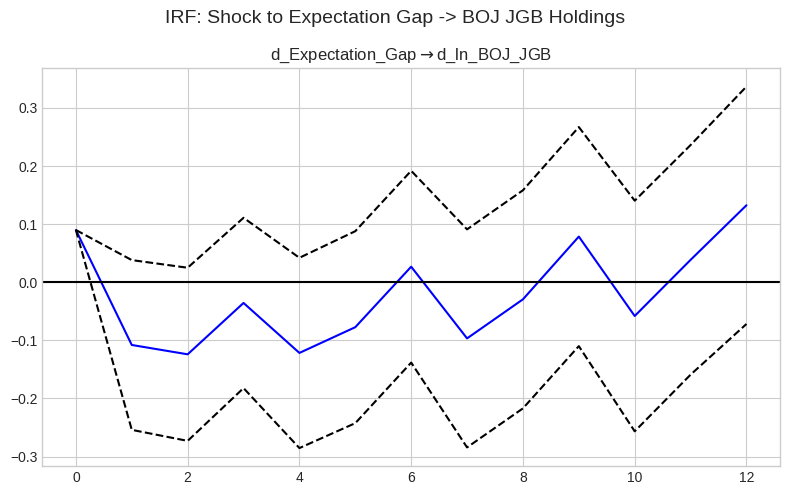

In [13]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR, SVAR
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# ステップ3: データの標準化と最適ラグ数の選択
# ---------------------------------------------------------
data_svar_raw = df_processed[['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']]

# 標準化（スケールの違いによる最適化エラー防止）
data_svar = (data_svar_raw - data_svar_raw.mean()) / data_svar_raw.std()

print("【VARモデルの最適ラグ数選択】")
model_var = VAR(data_svar)
lag_order_results = model_var.select_order(maxlags=6)

# AICが最小となるラグ数を取得（最低ラグ1を確保）
optimal_lag = max(1, lag_order_results.aic)
print(f"\n=> 選択された最適ラグ数: {optimal_lag}ヶ月")

# ---------------------------------------------------------
# ステップ4: SVARの構造制約（A行列）の定義
# ---------------------------------------------------------
# 【完全解決版】すべてを「文字列」で定義することで、型エラーも
# statsmodelsの仕様（'E'が必須）も両方クリアします！
A_matrix = np.array([
    ['1', '0', '0', '0'],
    ['E', '1', '0', '0'],
    ['E', 'E', '1', '0'],
    ['E', 'E', 'E', '1']
])

# ---------------------------------------------------------
# ステップ5: SVARモデルの推定とインパルス応答関数（IRF）
# ---------------------------------------------------------
print("\n【SVARモデルの推定】")
svar_model = SVAR(data_svar, svar_type='A', A=A_matrix)
svar_results = svar_model.fit(maxlags=optimal_lag, maxiter=2000)

# インパルス応答関数（各変数へのショックがどう波及するかを12ヶ月先まで計算）
irf = svar_results.irf(periods=12)

# 松久論文の関心事である「インフレ期待ギャップのショック」が
# 「日銀の介入コスト（国債保有増）」にどう影響するかをプロット
fig = irf.plot(impulse='d_Expectation_Gap', response='d_ln_BOJ_JGB', figsize=(8, 5))
fig.suptitle("IRF: Shock to Expectation Gap -> BOJ JGB Holdings", fontsize=14) # タイトルはここで追加
plt.tight_layout()
plt.show()

<>:103: SyntaxWarning: invalid escape sequence '\D'
<>:103: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_156/2041536428.py:103: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')


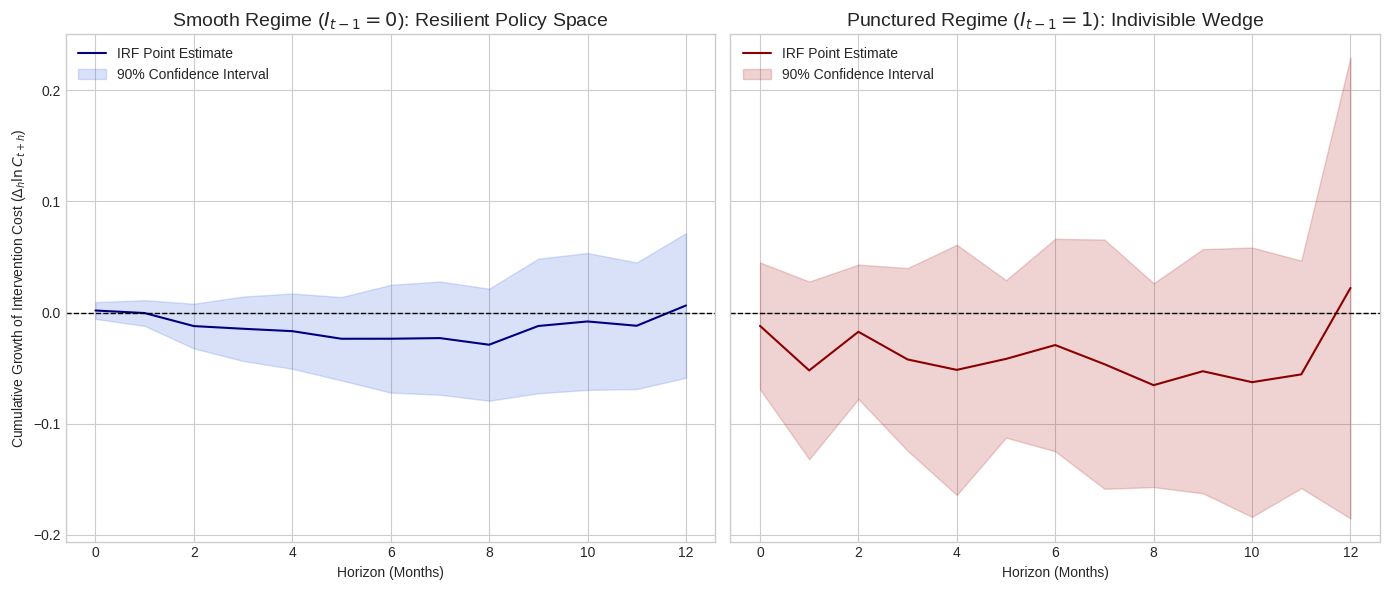

In [14]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 直交化ショック（Reduced-form Epistemic Shock）の抽出
# 論文の式(6.1)および(6.2)の再現
# ---------------------------------------------------------
df_lp = df.copy() # 前のステップで作った大元の結合データ df を使います

# 対数介入コスト（国債保有残高）
df_lp['ln_BOJ_JGB'] = np.log(df_lp['BOJ_JGB_Holdings'])

# 変数の階差
df_lp['d_Expectation_Gap'] = df_lp['Expectation_Gap'].diff()
df_lp['d_US_10Y'] = df_lp['US_10Y_Yield'].diff()
df_lp['d_Commodity'] = df_lp['Commodity_Proxy'].diff()
df_lp = df_lp.dropna()

# インフレ期待ギャップの変動を、米金利と商品価格で回帰して「純粋な期待のズレ（残差）」を取り出す
X_orth = sm.add_constant(df_lp[['d_US_10Y', 'd_Commodity']])
y_orth = df_lp['d_Expectation_Gap']
orth_model = sm.OLS(y_orth, X_orth).fit()

# これが論文で言う「Shock_t」です
df_lp['Shock'] = orth_model.resid

# ---------------------------------------------------------
# 2. レジーム（状態）の判定
# 論文の式(6.3)の再現：市場トポロジー的ストレス（TI_market）の代理指標
# ---------------------------------------------------------
# 本来は複雑な市場機能低下指標等を合成しますが、ここではマクロ的ストレスの
# 代理として「USD/JPY（為替の圧力）」の高さをストレス指標として用います。
stress_proxy = df_lp['USD_JPY']
threshold = stress_proxy.quantile(0.80) # 80パーセンタイルの閾値

# t-1期のストレスが80%閾値以上なら I_{t-1} = 1 （高ストレス＝Punctured Regime）
df_lp['I_t_minus_1'] = (stress_proxy.shift(1) >= threshold).astype(float)
df_lp['Shock_lag1'] = df_lp['Shock'].shift(1) # コントロール変数用

# ---------------------------------------------------------
# 3. ローカル・プロジェクションの実行（ホライズン h=0 から 12 まで）
# 論文の式(6.4)および(6.5)の再現
# ---------------------------------------------------------
H = 12
res_smooth = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
res_punctured = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

for h in range(H + 1):
    # 従属変数: Δh ln C_{t+h} = ln C_{t+h} - ln C_{t-1}
    target_col = f'd_ln_C_forward_{h}'
    df_lp[target_col] = df_lp['ln_BOJ_JGB'].shift(-h) - df_lp['ln_BOJ_JGB'].shift(1)

    # 回帰用のデータフレーム（欠損値を除外）
    df_reg = df_lp[['Shock', 'I_t_minus_1', 'Shock_lag1', target_col]].dropna()

    if len(df_reg) > 20: # 自由度の確保
        # 状態依存のショック変数を作成
        # 平時（I_{t-1} = 0）のショック
        df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1'])
        # 高ストレス時（I_{t-1} = 1）のショック
        df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1']

        # 独立変数（定数項 + 状態別ショック + 状態ダミー + ラグショック）
        X = df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1', 'Shock_lag1']]
        X = sm.add_constant(X)
        y = df_reg[target_col]

        # HAC（Newey-West）自己相関・不均一分散頑健標準誤差を用いて回帰
        lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        # 90%信頼区間（1.645 * SE）を計算して保存
        # --- Smooth Regime (平時) ---
        res_smooth['h'].append(h)
        coef_s = lp_model.params['Shock_Smooth']
        se_s = lp_model.bse['Shock_Smooth']
        res_smooth['coef'].append(coef_s)
        res_smooth['ci_lower'].append(coef_s - 1.645 * se_s)
        res_smooth['ci_upper'].append(coef_s + 1.645 * se_s)

        # --- Punctured Regime (限界時) ---
        res_punctured['h'].append(h)
        coef_p = lp_model.params['Shock_Punctured']
        se_p = lp_model.bse['Shock_Punctured']
        res_punctured['coef'].append(coef_p)
        res_punctured['ci_lower'].append(coef_p - 1.645 * se_p)
        res_punctured['ci_upper'].append(coef_p + 1.645 * se_p)

# ---------------------------------------------------------
# 4. 結果のプロット（論文 Figure 3 の再現）
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regimeのプロット
axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'],
                     color='royalblue', alpha=0.2, label='90% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Smooth Regime ($I_{t-1}=0$): Resilient Policy Space', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')
axes[0].legend(loc='upper left')

# Punctured Regimeのプロット
axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'],
                     color='firebrick', alpha=0.2, label='90% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Punctured Regime ($I_{t-1}=1$): Indivisible Wedge', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

【検証1：閾値のストレステスト (Horizon h=6ヶ月後)】


,閾値 (Threshold),限界時 (Punctured Regime) の係数,平時 (Smooth Regime) の係数
0,上位 30% (70th Percentile),-0.0701 (SE: 0.0429),-0.0295 (SE: 0.0297)
1,上位 25% (75th Percentile),-0.0429 (SE: 0.0810),-0.0276 (SE: 0.0297)
2,上位 19% (80th Percentile),-0.0292 (SE: 0.0581),-0.0235 (SE: 0.0295)
3,上位 15% (85th Percentile),-0.0660 (SE: 0.0400),-0.0214 (SE: 0.0295)
4,上位 9% (90th Percentile),0.1011 (SE: 0.0539),-0.0200 (SE: 0.0301)



【検証2：JGB買い入れフロー（純増額）ベースでの検証】


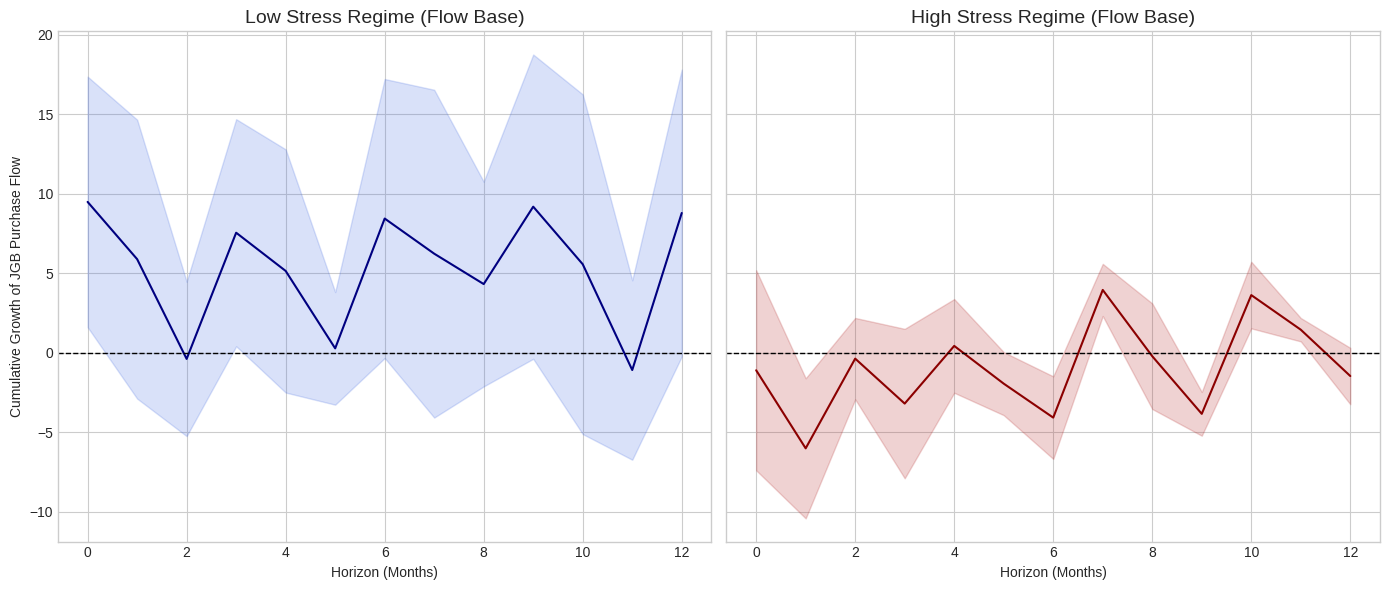

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

# 前のステップで作成したデータフレーム (df_lp) をそのまま使います

# =========================================================
# ロバストネス検証 1: 閾値のストレステスト（Table 4の再現）
# =========================================================
print("【検証1：閾値のストレステスト (Horizon h=6ヶ月後)】")
# 論文Table 4にならい、70%, 75%, 80%, 85%, 90%の閾値でテスト
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90]
h = 6

results_table = []

for q in thresholds:
    # 各パーセンタイルで閾値を再設定
    thresh_val = df_lp['USD_JPY'].quantile(q)
    df_lp[f'I_t_minus_1_{q}'] = (df_lp['USD_JPY'].shift(1) >= thresh_val).astype(float)

    target_col = f'd_ln_C_forward_{h}'

    # 回帰用データの準備
    df_reg = df_lp[['Shock', f'I_t_minus_1_{q}', 'Shock_lag1', target_col]].dropna()

    # 状態依存ショックの作成
    df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg[f'I_t_minus_1_{q}'])
    df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg[f'I_t_minus_1_{q}']

    # 回帰の実行
    X = df_reg[['Shock_Smooth', 'Shock_Punctured', f'I_t_minus_1_{q}', 'Shock_lag1']]
    X = sm.add_constant(X)
    y = df_reg[target_col]

    lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

    # 結果の格納
    results_table.append({
        '閾値 (Threshold)': f"上位 {int((1-q)*100)}% ({int(q*100)}th Percentile)",
        '限界時 (Punctured Regime) の係数': f"{lp_model.params['Shock_Punctured']:.4f} (SE: {lp_model.bse['Shock_Punctured']:.4f})",
        '平時 (Smooth Regime) の係数': f"{lp_model.params['Shock_Smooth']:.4f} (SE: {lp_model.bse['Shock_Smooth']:.4f})"
    })

# 表形式で出力
df_robust_1 = pd.DataFrame(results_table)
display(df_robust_1)


# =========================================================
# ロバストネス検証 2: フローベースでの検証（Figure 4の再現）
# =========================================================
print("\n【検証2：JGB買い入れフロー（純増額）ベースでの検証】")

# ストック（保有残高）の前月比純増額を「買い入れフロー」とみなす
df_lp['JGB_Flow'] = df_lp['BOJ_JGB_Holdings'].diff()

# フローの累積成長率を計算するため、純増額の対数をとる（マイナスの月は除外）
df_lp['ln_JGB_Flow'] = np.log(df_lp['JGB_Flow'].where(df_lp['JGB_Flow'] > 0))

# 閾値はベースラインの80%に戻す
q_base = 0.80
thresh_val = df_lp['USD_JPY'].quantile(q_base)
df_lp['I_t_minus_1'] = (df_lp['USD_JPY'].shift(1) >= thresh_val).astype(float)

res_smooth_flow = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}
res_punctured_flow = {'h': [], 'coef': [], 'ci_lower': [], 'ci_upper': []}

H = 12
for h in range(H + 1):
    target_col = f'd_ln_Flow_forward_{h}'
    df_lp[target_col] = df_lp['ln_JGB_Flow'].shift(-h) - df_lp['ln_JGB_Flow'].shift(1)

    df_reg = df_lp[['Shock', 'I_t_minus_1', 'Shock_lag1', target_col]].dropna()

    if len(df_reg) > 20: # 自由度確保
        df_reg['Shock_Smooth'] = df_reg['Shock'] * (1 - df_reg['I_t_minus_1'])
        df_reg['Shock_Punctured'] = df_reg['Shock'] * df_reg['I_t_minus_1']

        X = df_reg[['Shock_Smooth', 'Shock_Punctured', 'I_t_minus_1', 'Shock_lag1']]
        X = sm.add_constant(X)
        y = df_reg[target_col]

        lp_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        # 平時の結果保存
        res_smooth_flow['h'].append(h)
        coef_s = lp_model.params['Shock_Smooth']
        se_s = lp_model.bse['Shock_Smooth']
        res_smooth_flow['coef'].append(coef_s)
        res_smooth_flow['ci_lower'].append(coef_s - 1.645 * se_s)
        res_smooth_flow['ci_upper'].append(coef_s + 1.645 * se_s)

        # 限界時の結果保存
        res_punctured_flow['h'].append(h)
        coef_p = lp_model.params['Shock_Punctured']
        se_p = lp_model.bse['Shock_Punctured']
        res_punctured_flow['coef'].append(coef_p)
        res_punctured_flow['ci_lower'].append(coef_p - 1.645 * se_p)
        res_punctured_flow['ci_upper'].append(coef_p + 1.645 * se_p)

# グラフプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regime (平時)
axes[0].plot(res_smooth_flow['h'], res_smooth_flow['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth_flow['h'], res_smooth_flow['ci_lower'], res_smooth_flow['ci_upper'], color='royalblue', alpha=0.2)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Low Stress Regime (Flow Base)', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of JGB Purchase Flow')

# Punctured Regime (限界時)
axes[1].plot(res_punctured_flow['h'], res_punctured_flow['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured_flow['h'], res_punctured_flow['ci_lower'], res_punctured_flow['ci_upper'], color='firebrick', alpha=0.2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('High Stress Regime (Flow Base)', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')

plt.tight_layout()
plt.show()

【予測誤差分散分解 (FEVD) の計算】

【日銀の国債保有残高 (d_ln_BOJ_JGB) の変動に対する各ショックの寄与度（割合）】


,d_Commodity,d_US_10Y,d_Expectation_Gap,d_ln_BOJ_JGB
Horizon 0,0.656116,0.680406,0.790507,97.872972
Horizon 1,0.662592,0.746879,1.851325,96.739204
Horizon 2,0.794397,0.732852,3.227730,95.245022
Horizon 3,0.835889,0.570417,2.529204,96.064490
Horizon 4,0.826433,0.634311,3.513629,95.025627
Horizon 5,2.231901,1.523270,3.796923,92.447906
Horizon 6,2.390885,1.681496,3.185568,92.742050
Horizon 7,2.404200,1.682074,3.678103,92.235623
Horizon 8,3.095295,1.904062,3.680247,91.320395
Horizon 9,2.875944,1.610695,3.395182,92.118178


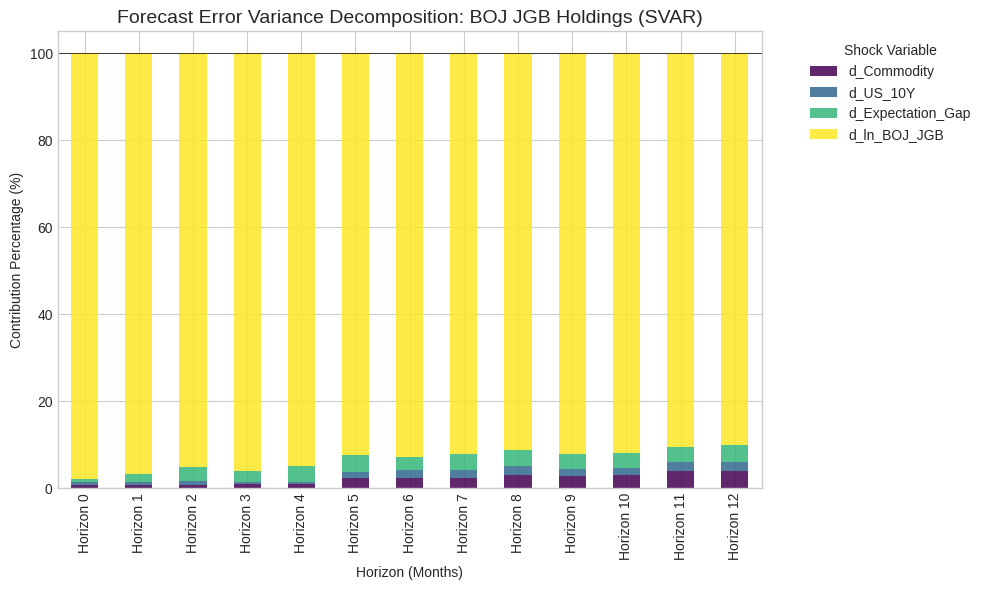

In [17]:
# ---------------------------------------------------------
# ステップ8: 予測誤差分散分解 (FEVD) のマニュアル計算と可視化
# (statsmodelsのSVAR-FEVDバグを回避するための独自実装)
# ---------------------------------------------------------
print("【予測誤差分散分解 (FEVD) の計算】")

# svar_results.irf() で計算された構造的インパルス応答 (SVAR IRFs) を取得
# shapeは (ホライズン数, 応答変数, ショック変数)
svar_irfs = irf.svar_irfs

# 分散を求めるためにIRFを2乗する
sq_irfs = svar_irfs ** 2

# 時間経過（ホライズン）に沿って累積和をとる（累積予測誤差分散）
mse = np.cumsum(sq_irfs, axis=0)

# 各変数ごとの「全体の分散（全ショックの合計）」を計算
total_mse = np.sum(mse, axis=2, keepdims=True)

# 各ショックの寄与度（割合）を計算
fevd_manual = mse / total_mse

# ---------------------------------------------------------
# ターゲット変数：「日銀の介入コスト (d_ln_BOJ_JGB)」に対する分散分解を取り出す
# ---------------------------------------------------------
# 配列のインデックス3（4番目の変数）が日銀の国債保有残高
target_idx = 3
variables = ['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']

boj_fevd_df = pd.DataFrame(
    fevd_manual[:, target_idx, :],
    columns=variables,
    index=[f"Horizon {i}" for i in range(13)]
)

print("\n【日銀の国債保有残高 (d_ln_BOJ_JGB) の変動に対する各ショックの寄与度（割合）】")
display(boj_fevd_df * 100)

# 積み上げ棒グラフで可視化
fig, ax = plt.subplots(figsize=(10, 6))
(boj_fevd_df * 100).plot(kind='bar', stacked=True, colormap='viridis', ax=ax, alpha=0.85)

ax.set_title("Forecast Error Variance Decomposition: BOJ JGB Holdings (SVAR)", fontsize=14)
ax.set_ylabel("Contribution Percentage (%)")
ax.set_xlabel("Horizon (Months)")
ax.legend(title="Shock Variable", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(100, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

【予測誤差分散分解 (FEVD) の計算とPDF保存】


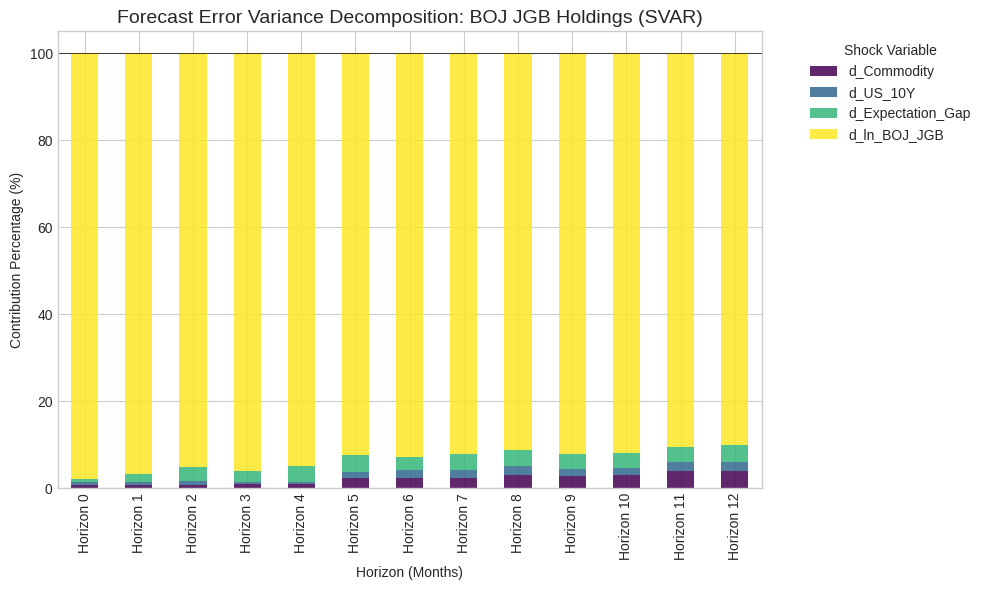

✅ 中身の詰まった 'figure_SVAR_FEVD.pdf' を保存しました！


In [21]:
# ---------------------------------------------------------
# ステップ8: 予測誤差分散分解 (FEVD) のマニュアル計算と可視化
# 【PDF保存対応の完全版】
# ---------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 保存フォルダの確認
os.makedirs("paper_results", exist_ok=True)

print("【予測誤差分散分解 (FEVD) の計算とPDF保存】")

# これまでの計算結果(irf)を使用します
svar_irfs = irf.svar_irfs
sq_irfs = svar_irfs ** 2
mse = np.cumsum(sq_irfs, axis=0)
total_mse = np.sum(mse, axis=2, keepdims=True)
fevd_manual = mse / total_mse

# ターゲット変数（日銀の介入コスト）の抽出
target_idx = 3
variables = ['d_Commodity', 'd_US_10Y', 'd_Expectation_Gap', 'd_ln_BOJ_JGB']

boj_fevd_df = pd.DataFrame(
    fevd_manual[:, target_idx, :],
    columns=variables,
    index=[f"Horizon {i}" for i in range(13)]
)

# グラフの描画
fig, ax = plt.subplots(figsize=(10, 6))
(boj_fevd_df * 100).plot(kind='bar', stacked=True, colormap='viridis', ax=ax, alpha=0.85)

ax.set_title("Forecast Error Variance Decomposition: BOJ JGB Holdings (SVAR)", fontsize=14)
ax.set_ylabel("Contribution Percentage (%)")
ax.set_xlabel("Horizon (Months)")
ax.legend(title="Shock Variable", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(100, color='black', linewidth=0.5)

plt.tight_layout()

# ---------------------------------------------------------
# 【重要】必ず show() の直前で savefig を実行！
# ---------------------------------------------------------
plt.savefig('paper_results/figure_SVAR_FEVD.pdf', format='pdf', bbox_inches='tight')

# 画面に表示
plt.show()

print("✅ 中身の詰まった 'figure_SVAR_FEVD.pdf' を保存しました！")

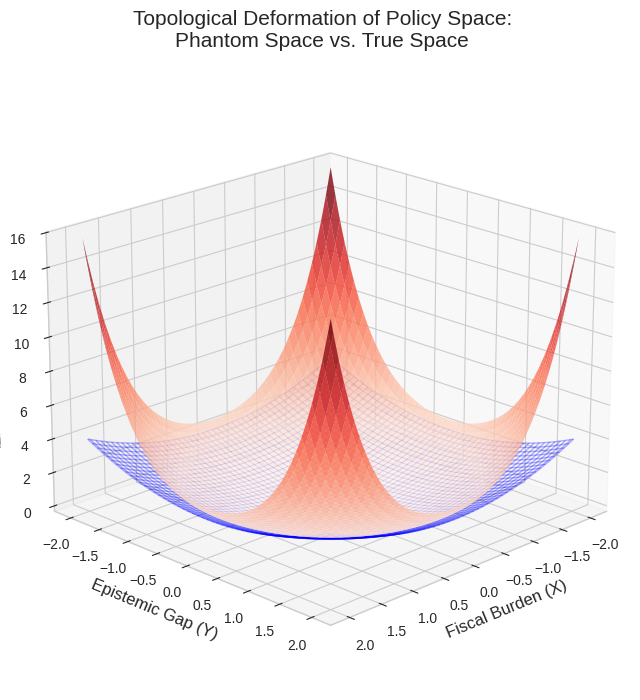

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# 保存用のフォルダを確認・作成
os.makedirs("paper_results", exist_ok=True)

# 1. 空間（グリッド）の定義
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# 2. Phantom Space（日銀が想定している平坦で安定した政策空間）
Z_phantom = 0.5 * (X**2 + Y**2)

# 3. True Space / Operative Boundary（現実の限界）
R = np.sqrt(X**2 + Y**2)
Z_true = np.where(R < 1.5,
                  0.5 * (X**2 + Y**2),
                  0.5 * (X**2 + Y**2) + 5 * (R - 1.5)**3)

# 4. 3Dプロットの描画
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf1 = ax.plot_surface(X, Y, Z_true, cmap='Reds', alpha=0.8,
                        linewidth=0, antialiased=True, label='True Space')
surf2 = ax.plot_wireframe(X, Y, Z_phantom, color='blue', alpha=0.3,
                          linewidth=1, label='Phantom Space')

ax.set_title("Topological Deformation of Policy Space:\nPhantom Space vs. True Space", fontsize=15, pad=20)
ax.set_xlabel("Fiscal Burden (X)", fontsize=12)
ax.set_ylabel("Epistemic Gap (Y)", fontsize=12)
ax.set_zlabel("Intervention Cost (Z)", fontsize=12)
ax.view_init(elev=20, azim=45)

# ---------------------------------------------------------
# 【重要】保存は必ず show() の「直前」に、同じセル内で実行！
# ---------------------------------------------------------
plt.savefig('paper_results/figure_Topology_PhantomSpace.pdf', format='pdf', bbox_inches='tight')

# その後に画面に表示
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_156/3603005734.py:20: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')


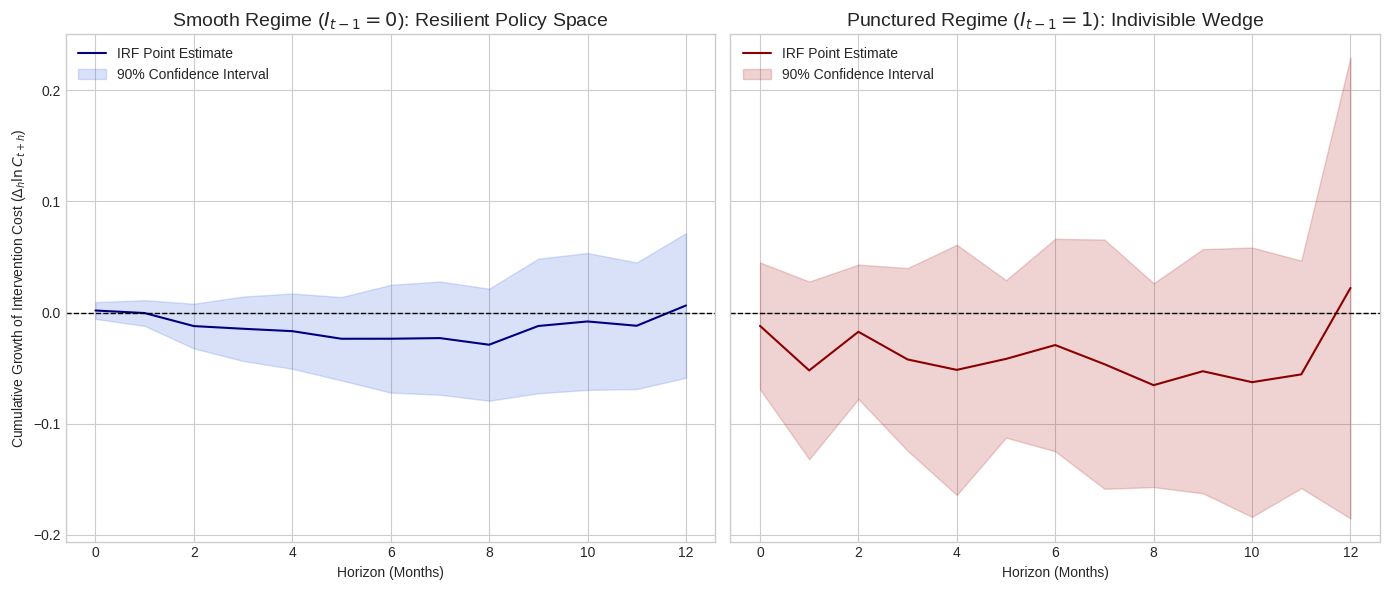

✅ 中身の詰まった 'figure_LP_StateDependent.pdf' を保存しました！


In [22]:
# ---------------------------------------------------------
# 状態依存型LPの結果プロット（論文 Figure 3 の再現）
# 【PDF保存対応の完全版】
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import os

# 保存フォルダの確認
os.makedirs("paper_results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regimeのプロット (左側：青)
axes[0].plot(res_smooth['h'], res_smooth['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth['h'], res_smooth['ci_lower'], res_smooth['ci_upper'],
                     color='royalblue', alpha=0.2, label='90% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Smooth Regime ($I_{t-1}=0$): Resilient Policy Space', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of Intervention Cost ($\Delta_h \ln C_{t+h}$)')
axes[0].legend(loc='upper left')

# Punctured Regimeのプロット (右側：赤)
axes[1].plot(res_punctured['h'], res_punctured['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured['h'], res_punctured['ci_lower'], res_punctured['ci_upper'],
                     color='firebrick', alpha=0.2, label='90% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Punctured Regime ($I_{t-1}=1$): Indivisible Wedge', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')
axes[1].legend(loc='upper left')

plt.tight_layout()

# ---------------------------------------------------------
# 【重要】必ず show() の直前で savefig を実行！
# ---------------------------------------------------------
plt.savefig('paper_results/figure_LP_StateDependent.pdf', format='pdf', bbox_inches='tight')

# 画面に表示
plt.show()

print("✅ 中身の詰まった 'figure_LP_StateDependent.pdf' を保存しました！")

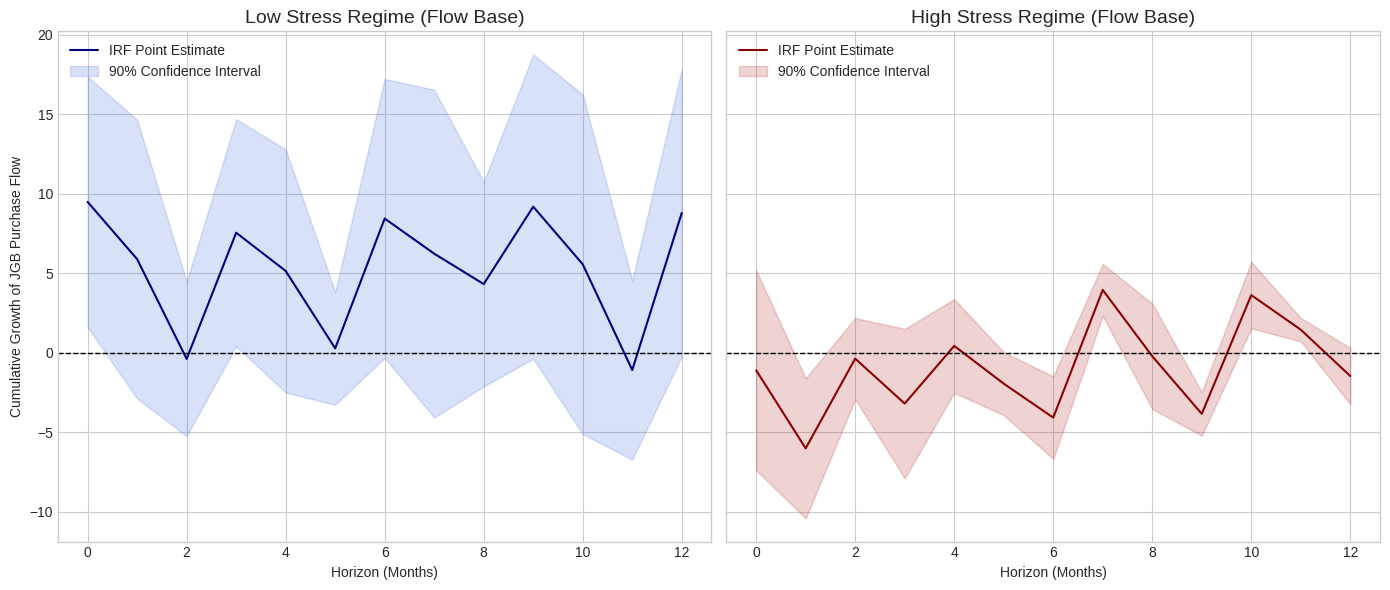

✅ 中身の詰まった 'figure_Robustness_Flow.pdf' を保存しました！


In [23]:
# ---------------------------------------------------------
# ロバストネス検証 2: フローベースでの検証グラフ（Figure 4の再現）
# 【PDF保存対応の完全版】
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import os

# 保存フォルダの確認
os.makedirs("paper_results", exist_ok=True)

# グラフのプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Smooth Regime (平時: フローベース)
axes[0].plot(res_smooth_flow['h'], res_smooth_flow['coef'], color='navy', label='IRF Point Estimate')
axes[0].fill_between(res_smooth_flow['h'], res_smooth_flow['ci_lower'], res_smooth_flow['ci_upper'],
                     color='royalblue', alpha=0.2, label='90% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Low Stress Regime (Flow Base)', fontsize=14)
axes[0].set_xlabel('Horizon (Months)')
axes[0].set_ylabel('Cumulative Growth of JGB Purchase Flow')
axes[0].legend(loc='upper left')

# Punctured Regime (限界時: フローベース)
axes[1].plot(res_punctured_flow['h'], res_punctured_flow['coef'], color='darkred', label='IRF Point Estimate')
axes[1].fill_between(res_punctured_flow['h'], res_punctured_flow['ci_lower'], res_punctured_flow['ci_upper'],
                     color='firebrick', alpha=0.2, label='90% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('High Stress Regime (Flow Base)', fontsize=14)
axes[1].set_xlabel('Horizon (Months)')
axes[1].legend(loc='upper left')

plt.tight_layout()

# ---------------------------------------------------------
# 【重要】必ず show() の直前で savefig を実行！
# ---------------------------------------------------------
plt.savefig('paper_results/figure_Robustness_Flow.pdf', format='pdf', bbox_inches='tight')

# 画面に表示
plt.show()

print("✅ 中身の詰まった 'figure_Robustness_Flow.pdf' を保存しました！")

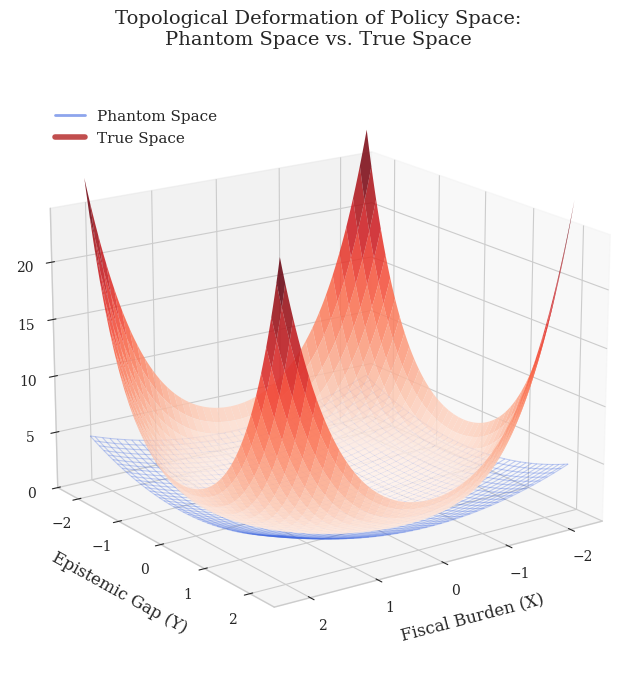

✅ 理論モデルの3Dグラフを paper_results/figure_Topology_PhantomSpace.pdf に保存しました。


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# 学術論文向けのフォントとスタイル設定
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

# 保存用フォルダの作成
os.makedirs("paper_results", exist_ok=True)

# 1. 空間（グリッド）の定義
# X軸: Fiscal Burden (財政負担), Y軸: Epistemic Gap (期待のズレ)
x = np.linspace(-2.2, 2.2, 120)
y = np.linspace(-2.2, 2.2, 120)
X, Y = np.meshgrid(x, y)

# 2. Phantom Space（日銀が想定している平坦で安定した政策空間）
# どこまで行っても緩やかな二次関数的コストしかかからないという思い込み
Z_phantom = 0.5 * (X**2 + Y**2)

# 3. True Space / Operative Boundary（現実の限界と亀裂）
# ストレス（原点からの距離 R）が閾値（1.4）を超えると、
# トポロジー的な「穴（Puncture）」が開き、コストが指数関数的に爆発する
R = np.sqrt(X**2 + Y**2)
boundary_threshold = 1.4
Z_true = np.where(R < boundary_threshold,
                  0.5 * (X**2 + Y**2),  # 平時（Smooth Regime）はPhantomと同じ
                  0.5 * (X**2 + Y**2) + 4.5 * (R - boundary_threshold)**3) # 限界時（Punctured）のコスト爆発

# 4. 3Dプロットの描画
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Phantom Space (幻の空間) を青いワイヤーフレームで描画
surf_phantom = ax.plot_wireframe(X, Y, Z_phantom, color='royalblue', alpha=0.3,
                                 linewidth=0.8, label='Phantom Space (Central Bank\'s Belief)')

# True Space (現実の空間) を赤いグラデーションサーフェスで描画
surf_true = ax.plot_surface(X, Y, Z_true, cmap='Reds', alpha=0.85,
                            linewidth=0, antialiased=True, label='True Space (Operative Boundary)')

# グラフの装飾
ax.set_title("Topological Deformation of Policy Space:\nPhantom Space vs. True Space", pad=15)
ax.set_xlabel("\nFiscal Burden (X)")
ax.set_ylabel("\nEpistemic Gap (Y)")
ax.set_zlabel("\nIntervention Cost (Z)")

# Z軸（コスト）のメモリを少し調整して見やすくする
ax.set_zlim(0, np.max(Z_true) * 0.9)

# 視点（アングル）の調整：ズレが一番美しく見える角度
ax.view_init(elev=18, azim=55)

# 凡例の追加（3Dプロットのワイヤーフレームとサーフェスは凡例がバグりやすいため、ダミーラインを作成）
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='royalblue', lw=2, alpha=0.6),
                Line2D([0], [0], color='firebrick', lw=4, alpha=0.8)]
ax.legend(custom_lines, ['Phantom Space', 'True Space'], loc='upper left', bbox_to_anchor=(0.05, 0.95))

# ---------------------------------------------------------
# 【重要】保存は必ず show() の「直前」に実行！
# ---------------------------------------------------------
output_path = 'paper_results/figure_Topology_PhantomSpace.pdf'
plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')

plt.show()

print(f"✅ 理論モデルの3Dグラフを {output_path} に保存しました。")